# Benchmark — Random Forest + Feature Engineering V1

- **Dataset** : `features_V1.csv` (X_train_sample + y_train_sample + RET_1_TURNOVER)
- **Modèle** : Random Forest avec hyperparameter optimization (Optuna)
- **Validation** : 90/10 train/validation split

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

try:
    import optuna
    import logging
    logging.getLogger("optuna").setLevel(logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    from sklearn.model_selection import RandomizedSearchCV
    HAS_OPTUNA = False
    print('Optuna non disponible, utilisation de RandomizedSearchCV')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


## 1. Chargement & Préparation

In [15]:
# Charger features_V1.csv (contient déjà RET_1_TURNOVER + target)
df = pd.read_csv('features_V1.csv')
print(f'Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

# Target binaire
df['target_SIGN'] = (df['target'] > 0).astype(int)

# Colonnes features
exclude_cols = ['ROW_ID', 'TS', 'ALLOCATION', 'target', 'target_SIGN']
feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f'Features ({len(feature_cols)}) : {feature_cols}')

Dataset : 50,000 lignes × 56 colonnes
Features (52) : ['RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP', 'RET_1_TURNOVER', 'RET_MEAN_5', 'RET_MEAN_20', 'RET_STD_5', 'RET_STD_20', 'RET_CUM_5', 'RET_CUM_20', 'RET_POSITIVE_COUNT_5', 'RET_POSITIVE_COUNT_20', 'RET_RECENT_VS_OLD']


In [16]:
df = pd.read_csv('features_V1.csv')
print(df.head())

   ROW_ID         TS      ALLOCATION    RET_20    RET_19    RET_18    RET_17  \
0   54916  DATE_0273   ALLOCATION_04  0.001418 -0.005199 -0.001927 -0.005260   
1  173590  DATE_0833  ALLOCATION_232  0.001403  0.001136  0.000942 -0.000066   
2  467223  DATE_2233  ALLOCATION_194 -0.001004 -0.001696  0.007416 -0.004928   
3   87696  DATE_0427  ALLOCATION_155 -0.000611 -0.000932  0.001631  0.001376   
4  502178  DATE_2406  ALLOCATION_227  0.001423 -0.002167 -0.002938 -0.001488   

     RET_16    RET_15    RET_14  ...  RET_1_TURNOVER  RET_MEAN_5  RET_MEAN_20  \
0  0.001290 -0.007002 -0.005132  ...       -0.000013   -0.004761    -0.002562   
1  0.001249 -0.001917 -0.000179  ...        0.000003    0.000841     0.000577   
2  0.002904  0.001848  0.000629  ...        0.000027   -0.000577     0.000491   
3  0.001931  0.000390  0.001518  ...        0.000006    0.000005     0.000191   
4  0.001576  0.000958 -0.000114  ...        0.000069    0.000388    -0.000077   

   RET_STD_5  RET_STD_20  RET_CU

## 2. Preprocessing (normalisation par groupe)

In [18]:
X = df[feature_cols].fillna(0).copy()
df['target_SIGN'] = (df['target'] > 0).astype(int)
y = df['target_SIGN'].copy()

# Normalisation intra-groupe
numeric_cols = [c for c in feature_cols if c != 'GROUP']
for grp in X['GROUP'].unique():
    mask = X['GROUP'] == grp
    scaler = StandardScaler()
    X.loc[mask, numeric_cols] = scaler.fit_transform(X.loc[mask, numeric_cols])

print('Normalisation par groupe terminée.')
print(f'Target distribution : {y.value_counts(normalize=True).to_dict()}')

Normalisation par groupe terminée.
Target distribution : {1: 0.50836, 0: 0.49164}


## 3. Split 90/10 (Train / Validation)

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.10, random_state=SEED, stratify=y
)

print(f'Train : {X_train.shape[0]:,} exemples')
print(f'Val   : {X_val.shape[0]:,} exemples')
print(f'Val target distribution : {y_val.value_counts(normalize=True).to_dict()}')

Train : 45,000 exemples
Val   : 5,000 exemples
Val target distribution : {1: 0.5084, 0: 0.4916}


## 4. Hyperparameter Optimization

In [21]:
from sklearn.model_selection import RandomizedSearchCV

print('=== RandomizedSearchCV (rapide) ===')

param_distributions = {
    'n_estimators': [100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions,
    n_iter=15,
    cv=3,
    scoring='accuracy',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

best_params = search.best_params_
best_cv_score = search.best_score_

print(f'\nMeilleur score CV : {best_cv_score:.4f}')
print(f'Meilleurs paramètres :')
for k, v in best_params.items():
    print(f'  {k}: {v}')

=== RandomizedSearchCV (rapide) ===
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Meilleur score CV : 0.5305
Meilleurs paramètres :
  n_estimators: 100
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 15


## 5. Évaluation sur le Validation Set (10%)

In [22]:
# Entraîner le meilleur modèle sur tout le train set
best_rf = RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1)
best_rf.fit(X_train, y_train)

# Prédire sur le validation set
y_pred = best_rf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred)

print(f'=== Validation Set (10%) ===')
print(f'Accuracy : {val_accuracy:.4f}')
print(f'\nClassification Report :')
print(classification_report(y_val, y_pred, target_names=['Down (0)', 'Up (1)']))

# Matrice de confusion
cm = confusion_matrix(y_val, y_pred)
print(f'Confusion Matrix :\n{cm}')

=== Validation Set (10%) ===
Accuracy : 0.5320

Classification Report :
              precision    recall  f1-score   support

    Down (0)       0.53      0.45      0.48      2458
      Up (1)       0.53      0.62      0.57      2542

    accuracy                           0.53      5000
   macro avg       0.53      0.53      0.53      5000
weighted avg       0.53      0.53      0.53      5000

Confusion Matrix :
[[1094 1364]
 [ 976 1566]]


## 6. Feature Importance

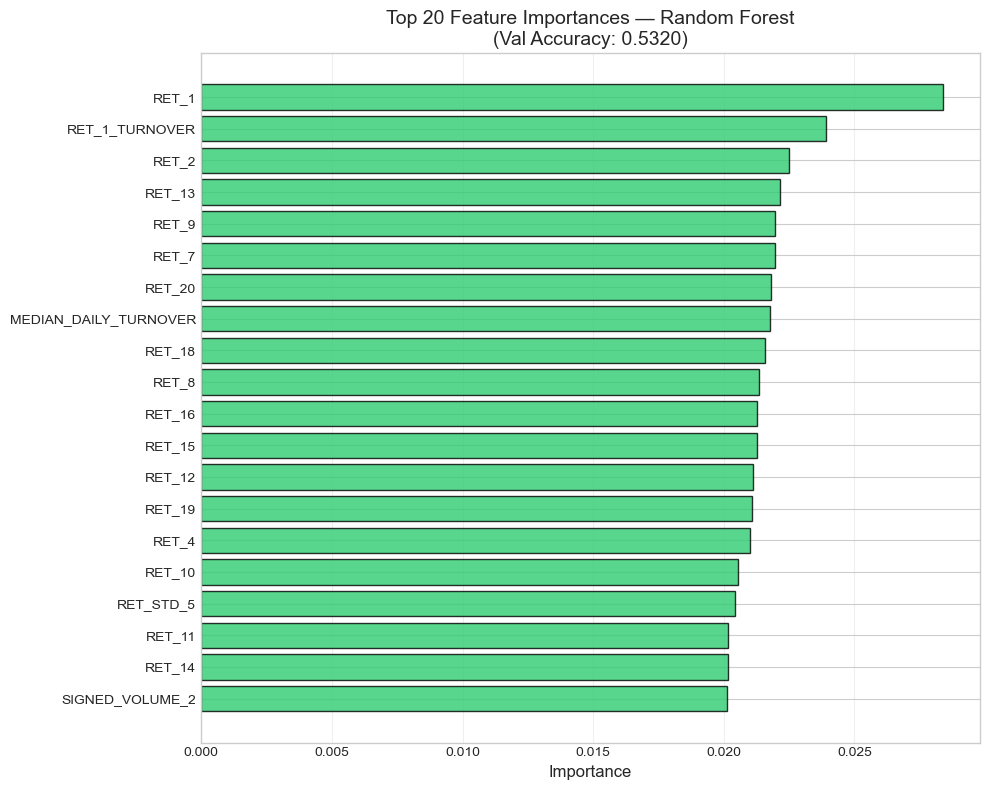


Top 10 features :
              Feature  Importance
                RET_8    0.021332
               RET_18    0.021562
MEDIAN_DAILY_TURNOVER    0.021759
               RET_20    0.021790
                RET_7    0.021965
                RET_9    0.021968
               RET_13    0.022158
                RET_2    0.022492
       RET_1_TURNOVER    0.023918
                RET_1    0.028385


In [23]:
# Feature importance du meilleur modèle
fi = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

# Top 20 features
top_fi = fi.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_fi['Feature'], top_fi['Importance'], color='#2ecc71', edgecolor='black', alpha=0.8)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title(f'Top 20 Feature Importances — Random Forest\n(Val Accuracy: {val_accuracy:.4f})', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('rf_feature_importance_V1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features :')
print(fi.tail(10).to_string(index=False))

## 7. Résumé

In [24]:
print('=' * 60)
print('RÉSUMÉ — Random Forest + Features V1')
print('=' * 60)
print(f'Dataset       : features_V1.csv ({df.shape[0]:,} lignes)')
print(f'Features      : {len(feature_cols)} (dont RET_1_TURNOVER)')
print(f'Train size    : {X_train.shape[0]:,} (90%)')
print(f'Val size      : {X_val.shape[0]:,} (10%)')
print(f'CV Accuracy   : {best_cv_score:.4f} (3-fold sur train)')
print(f'Val Accuracy  : {val_accuracy:.4f} (holdout 10%)')
print(f'Best params   : {best_params}')

RÉSUMÉ — Random Forest + Features V1
Dataset       : features_V1.csv (50,000 lignes)
Features      : 52 (dont RET_1_TURNOVER)
Train size    : 45,000 (90%)
Val size      : 5,000 (10%)
CV Accuracy   : 0.5305 (3-fold sur train)
Val Accuracy  : 0.5320 (holdout 10%)
Best params   : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}


In [25]:
import json
with open('best_params_rf.json', 'w') as f:
    json.dump(best_params, f)
print(f'Params sauvegardés dans best_params_rf.json : {best_params}')

Params sauvegardés dans best_params_rf.json : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}
